# 🪐 ExoWrap: Pythonic Radiative-Convective Atmospheric Modeling

Welcome to **ExoWrap**, a high-level Python framework designed to orchestrate, analyze, and automate planetary atmosphere simulations. 

Under the hood, `exowrap` acts as a smart wrapper for **ExoREM**, a powerful Fortran-based Radiative-Convective Equilibrium (RCE) model. It abstracts away the complexities of Fortran namelists, binary execution, and HDF5 file parsing, providing a seamless, object-oriented Python experience for generating planetary pressure-temperature profiles and synthetic spectra.


---

## 1. Architecture & Initialization

Because ExoREM is a compiled Fortran code, `exowrap` includes a Command Line Interface (CLI) to manage the backend. Before running any Python code, you must initialize the backend in your terminal. The CLI handles cloning the repository, patching the `Makefile` for your architecture, compiling the code, and saving the binary paths to `~/.exowrap/config.json`.

```bash
# In your terminal:
exowrap init
exowrap download-tables --res 50
```
Once initialized, the Simulation class in Python handles dynamically generating the Fortran .nml namelist files, mapping your simple dictionary parameters to the strict nested blocks expected by Fortran.

---
## 2. The Physics and Mathematics

`exowrap` processes the raw outputs from the Fortran solver and exposes them as physically meaningful, mathematically rigorous Python properties.


### 2.1 Atmospheric Structure & Thermodynamics
The atmospheric structure is defined by 1D arrays over pressure. The framework evaluates standard thermodynamic state variables, such as calculating the mass density profile ($\rho$) using the ideal gas law:

$$\rho = \frac{P \cdot M}{R \cdot T}$$

Where $P$ is the pressure profile, $M$ is the mean molar mass profile, $R$ is the universal gas constant, and $T$ is the temperature profile.

### 2.2 Synthetic Spectra Formulation
The solver outputs spectral radiosity evaluated on a wavenumber grid ($\tilde{\nu}$ in $\mathrm{cm}^{-1}$). `exowrap` mathematically converts this into standard astrophysical flux spaces:

* **Wavelength ($\lambda$):** Converted from wavenumber using $\lambda = 10000 / \tilde{\nu}$.
* **Flux Density ($F_\nu$):** Converted from radiosity using the speed of light. 
* **Janskys (Jy):** Calculated internally using the standard astronomical conversion $1 \text{ Jy} = 10^{-26} \text{ W m}^{-2} \text{ Hz}^{-1}$.
* **Flux per Wavelength ($F_\lambda$):** Computed using the Jacobian transformation $F_\lambda = \text{Radiosity} \times (10000 / \lambda^2)$.

It also parses Transmission spectra, representing the transit depth (the dimensionless fraction $(R_p/R_*)^2$).

---
## 3. Concrete Usage Examples

Let's run our first atmospheric model. We will configure the parameters, launch the simulation, and retrieve the results.

In [1]:
import numpy as np
from exowrap import Simulation

# 1. Define the physical parameters
params = {
    "T_int": 400.0,        # Internal heat flux in Kelvin
    "T_irr": 1100.0,       # Irradiation temperature in Kelvin
    "Met": 0.5,            # Metallicity (log10 Z/Z_solar)
    "kzz": 8.0,            # Eddy diffusion coefficient (log10 cm^2/s)
    "f_sed": 1.0           # Cloud sedimentation parameter
}

# 2. Initialize and run the simulation at Resolution = 50
print("Launching ExoREM...")
sim = Simulation(params=params, resolution=50, keep_run_files=False)
results_df = sim.run()

print("Simulation Complete!")

INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp_mf52eil/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


Launching ExoREM...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp_mf52eil/outputs/exowrap_run.h5...
INFO: Simulation complete.


Simulation Complete!


### Example 2: The `ExoremOut` Wrapper
The raw output of the simulation is a flattened Pandas DataFrame containing all the HDF5 paths. We wrap this in the `ExoremOut` class to gain object-oriented access to the physical arrays and properties.

In [2]:
from exowrap import ExoremOut

# Wrap the raw DataFrame
exo = ExoremOut(results_df)

# Print high-level scalar properties
print(f"Converged T_int: {exo.t_int:.1f} K")
print(f"Cloud Cover Fraction: {exo.cloud_cover:.2f}")
print(f"Retrieval Chi-Squared: {exo.chi2_retrieval:.2f}")

# Access 1D vertical profiles (NumPy arrays)
pressures = exo.pressure_profile
temperatures = exo.temperature_profile
gravity_profile = exo.gravity

# Access Dictionary-based data (like individual chemical absorbers)
water_vmr = exo.vmr_absorbers.get("H2O")
print(f"\nFound {len(exo.vmr_absorbers)} active absorbing species.")

# Generate a high-level statistical summary
summary = exo.summary()

Converged T_int: 375.2 K
Cloud Cover Fraction: 0.15
Retrieval Chi-Squared: 42885.05

Found 13 active absorbing species.


### Example 3: The High-Resolution Upgrader
Running a full radiative-convective equilibrium convergence at high spectral resolution (e.g., $R=500$ or $R=20,000$) is computationally expensive. 

`exowrap` provides an `upgrade_resolution` tool. It takes your converged low-resolution model, locks the P-T profile in place, and forces a $0$-iteration forward radiative transfer pass at the new resolution. This gives you high-fidelity spectra in seconds!

In [3]:
from exowrap import upgrade_resolution

# Upgrade the previously converged R=50 model to R=500!
# Note: You must run `exowrap download-tables --res 500` in your terminal first.

high_res_df = upgrade_resolution(
    results=exo,
    base_params=params,
    target_resolution=500,
    output_dir="./high_res_output"
)

exo_high_res = ExoremOut(high_res_df)
print(f"New spectral grid size: {len(exo_high_res.wavelength)} points!")

INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpio6thh19/input.nml


INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


🚀 Upgrading simulation to R=500...
💾 Locked P-T profile saved to: high_res_output/locked_pt_profile.dat
⚡ Executing 0-iteration forward pass...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpio6thh19/outputs/exowrap_run.h5...
INFO: 💾 Permanently saved HDF5 to: high_res_output/exorem_Tint400.0_gX.h5
INFO: Simulation complete.


🎉 High-resolution upgrade complete!
New spectral grid size: 1502 points!


### Example 4: Synthetic Photometry
If you want to compare your models directly to telescope observations (like JWST MIRI or NIRCam), you need synthetic photometry. `exowrap` integrates directly with the **SVO Filter Profile Service (FPS)**. It automatically downloads the transmission curve for any requested filter and integrates it over the ExoREM spectrum.

In [4]:
from exowrap import compute_photometry
from exowrap.photometry import search_svo_filters

# 1. Search for available JWST MIRI filters
miri_filters = search_svo_filters("JWST")
print("Found JWST filters:", miri_filters[:5], "...")

# 2. Compute synthetic photometry for the MIRI F1500W filter
filter_name = "JWST/MIRI.F1500W"

try:
    photometry = compute_photometry(
        exo=exo_high_res, 
        filter_id=filter_name, 
        photon_counting=True
    )
    
    print(f"\nPhotometry for {filter_name}:")
    print(f"Effective Wavelength: {photometry['effective_wavelength_um']:.2f} um")
    print(f"Flux (Jy): {photometry['flux_Jy']:.4e} Jy")
    
except Exception as e:
    print(f"Photometry failed: {e}")

Found JWST filters: ['JWST/MIRI.F1000W', 'JWST/MIRI.F1065C', 'JWST/MIRI.F1130W', 'JWST/MIRI.F1140C', 'JWST/MIRI.F1280W'] ...

Photometry for JWST/MIRI.F1500W:
Effective Wavelength: 15.09 um
Flux (Jy): 2.3373e+16 Jy


---
## 4. Visualization & Diagnostics

`exowrap` includes a comprehensive plotting suite tailored for publication-ready astrophysical figures. It can handle either the raw DataFrame or the `ExoremOut` object directly.

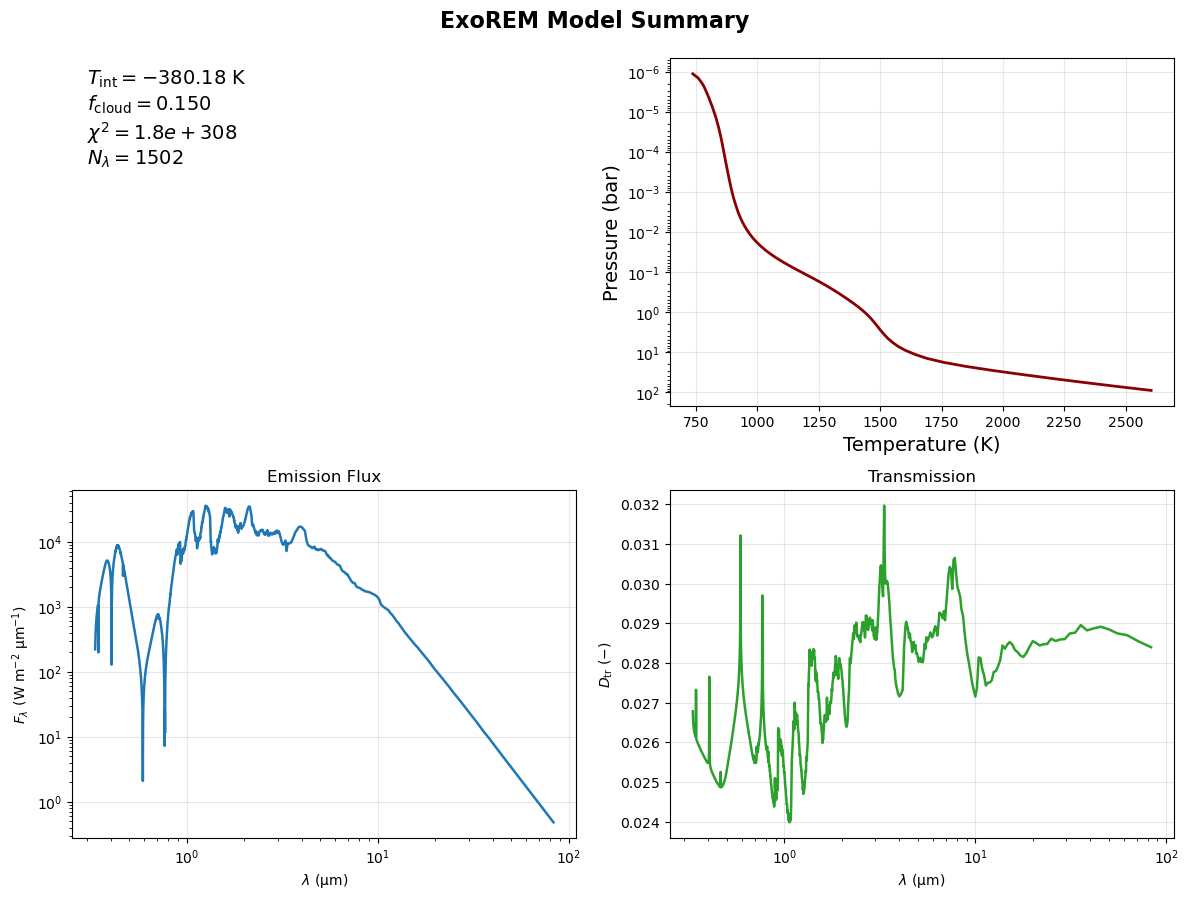

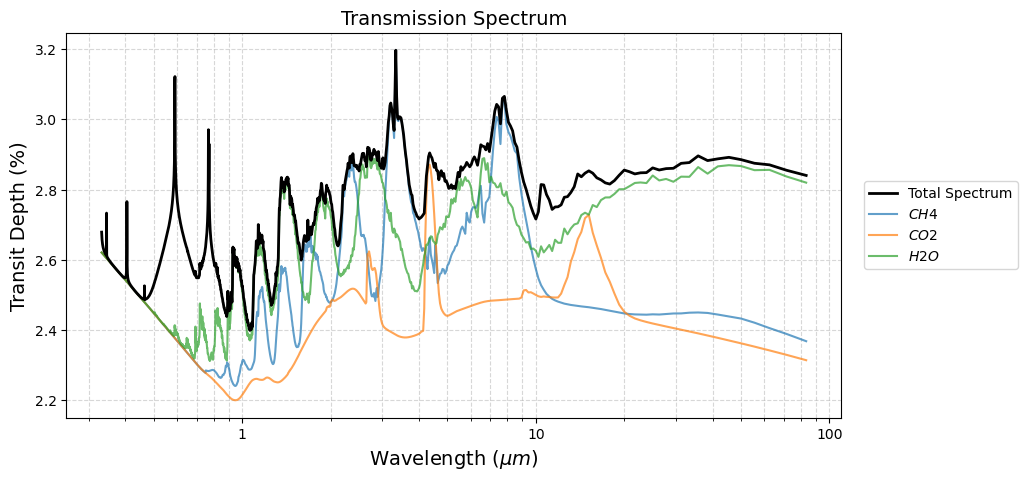

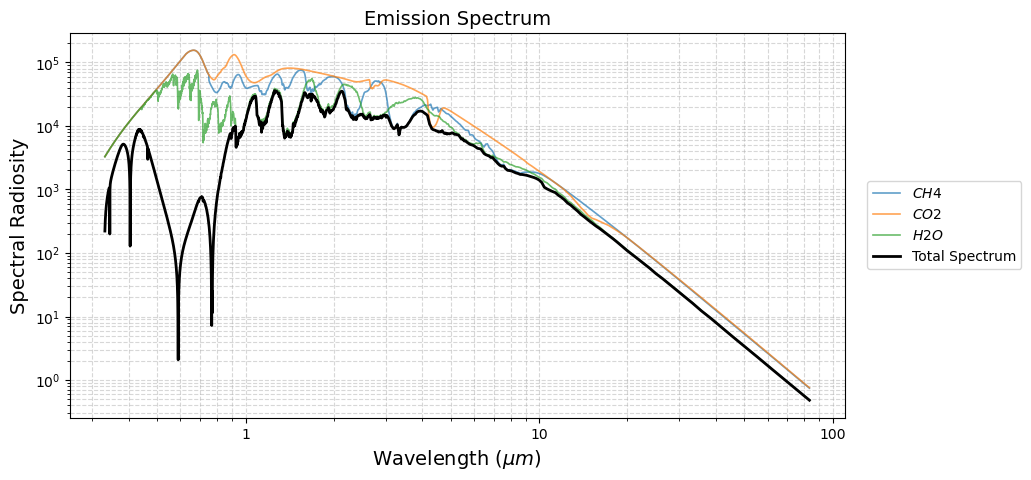

In [5]:
from exowrap import (
    plot_model_summary, 
    plot_tp_profile, 
    plot_transmission_spectrum, 
    plot_emission_spectrum
)
import matplotlib.pyplot as plt

# 1. Generate the complete 4-panel diagnostic summary
# (Includes Text Summary, P-T Profile, Emission Flux, and Transmission)
fig, axes = plot_model_summary(exo_high_res)
plt.show()

# 2. Plot specific detailed figures
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the transmission spectrum, breaking down the contributions from specific molecules
plot_transmission_spectrum(
    exo_high_res, 
    ax=ax, 
    contributions=["H2O", "CH4", "CO2"]
)
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))

# Plot the emission spectrum, breaking down the contributions from specific molecules
plot_emission_spectrum(
    exo_high_res, 
    ax=ax, 
    contributions=["H2O", "CH4", "CO2"]
)
plt.show()